In [ ]:
from google.colab import files

uploaded = files.upload()

Saving winequality-red.csv to winequality-red (1).csv


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("winequality-red.csv", sep=";")

print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8      

In [ ]:
X = df.drop("quality", axis=1)
y = df["quality"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Decision Tree Accuracy: 0.559375


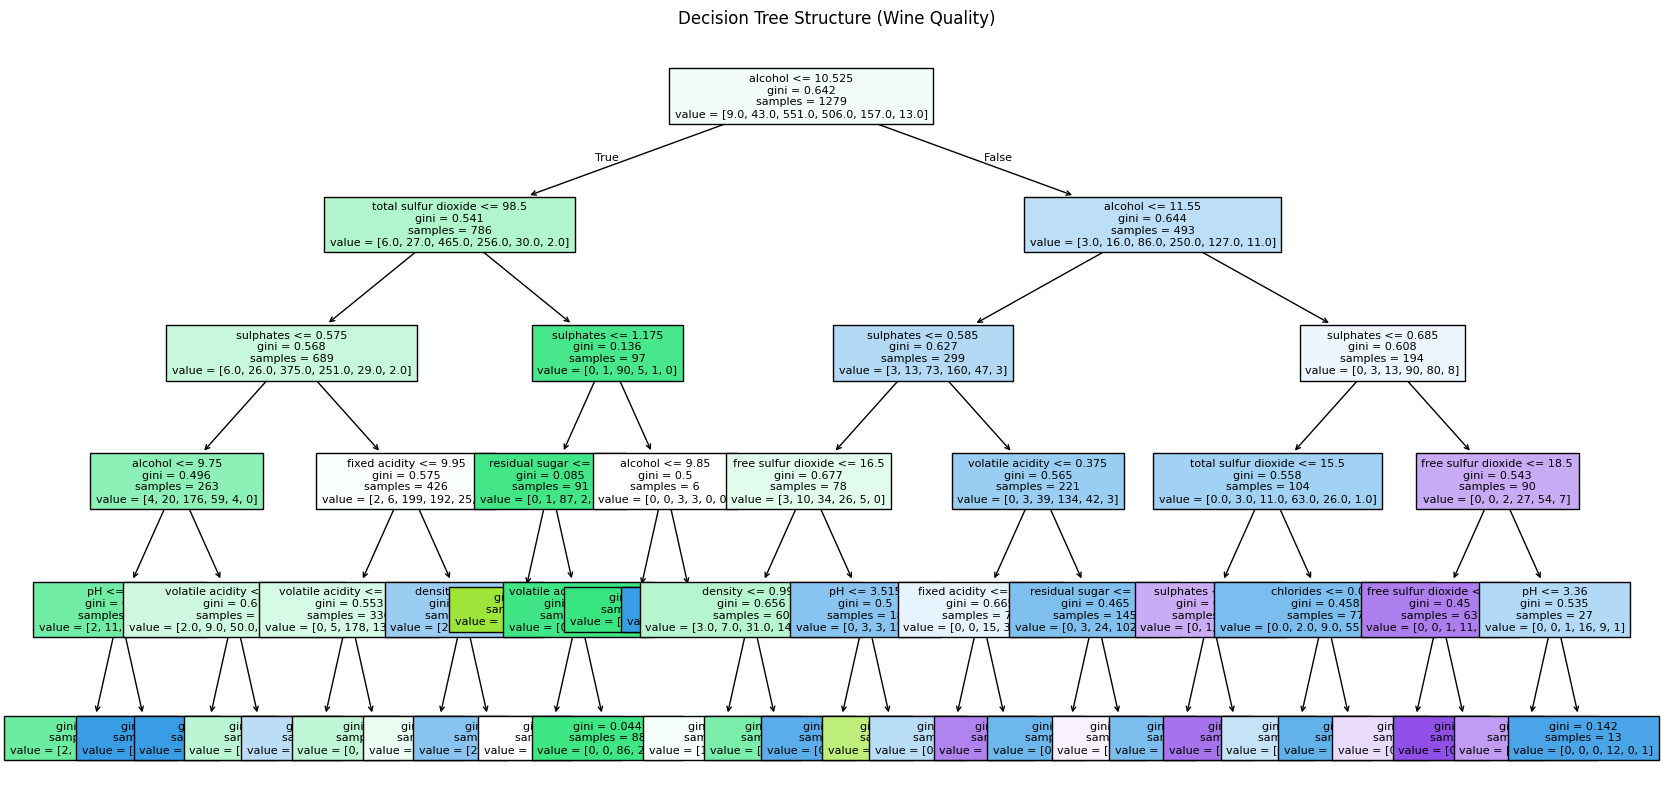

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("winequality-red.csv", sep=";")
X = df.drop("quality", axis=1)
y = df["quality"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

print("Decision Tree Accuracy:", dt.score(X_test, y_test))

# Visualize
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, filled=True, fontsize=8)
plt.title("Decision Tree Structure (Wine Quality)")
plt.show()


Random Forest Accuracy: 0.65625


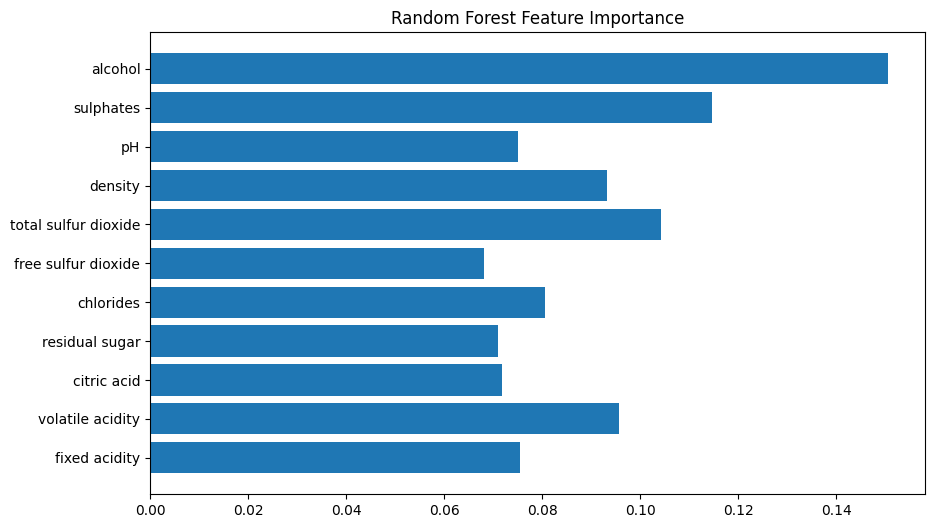

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

print("Random Forest Accuracy:", rf.score(X_test, y_test))

# Feature importance
importances = rf.feature_importances_
plt.figure(figsize=(10,6))
plt.barh(X.columns, importances)
plt.title("Random Forest Feature Importance")
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel="rbf", C=5, gamma=0.01)
svm.fit(X_train_scaled, y_train)

print("SVM Accuracy:", svm.score(X_test_scaled, y_test))


SVM Accuracy: 0.584375


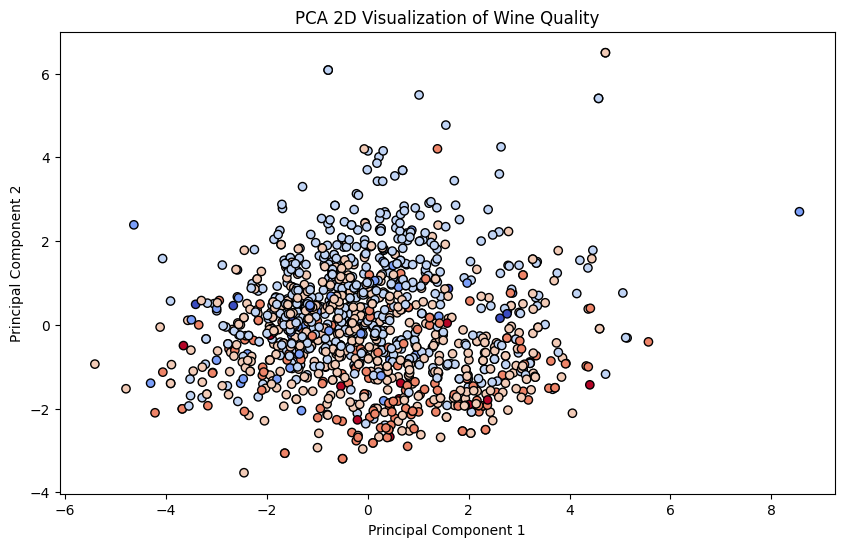

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap="coolwarm", edgecolors="k")
plt.title("PCA 2D Visualization of Wine Quality")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


In [ ]:
import numpy as np

# Binary reward setup
y_binary = (y >= 6).astype(int).values
states = len(X.columns)   # features as states
actions = 2               # classify as Good/Bad
Q = np.zeros((states, actions))

alpha, gamma, episodes = 0.1, 0.9, 200

for _ in range(episodes):
    state = np.random.randint(0, states)
    action = np.random.randint(0, actions)
    reward = np.random.choice([0,1])  # simplified reward
    next_state = (state+1) % states

    Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])

print("Q-Learning Table (Wine Quality Demo):\n", Q)


Q-Learning Table (Wine Quality Demo):
 [[0.62437483 0.40296427]
 [0.65068244 0.72806283]
 [0.74394521 0.55372802]
 [0.35170805 0.38535049]
 [0.37426158 0.3694537 ]
 [0.36278758 0.10405026]
 [0.35054154 0.51839008]
 [0.59306585 0.38593253]
 [0.63997148 0.57039908]
 [0.57338868 0.40427993]
 [0.69107463 0.61618575]]
